<a href="https://colab.research.google.com/github/mojordan235-oss/Project/blob/main/CMP414_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! ls ~/.kaggle
! chmod 600 ~/.kaggle/kaggle.json
! kaggle datasets list -s 'luna16'
! kaggle datasets download -d 'fanbyprinciple/luna-lung-cancer-dataset' --force
! unzip luna-lung-cancer-dataset.zip -d luna16

Saving kaggle.json to kaggle (1).json
mkdir: cannot create directory ‘/root/.kaggle’: File exists
kaggle.json
ref                                      title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------  ---------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
avc0706/luna16                           Luna16                                         34507100408  2020-11-19 04:17:45.270000           7113         69  0.64705884       
fanbyprinciple/luna-lung-cancer-dataset  Luna16 Lung Cancer Dataset                       346449017  2021-03-14 03:54:34.790000          10689         89  0.8235294        
vafaeii/luna16                           LUNA16 (v3)                                    66691721108  2026-03-04 19:31:51.683000            383         27  0.9411765        
amirrezamousavi/luna16   

# Project 1
# Malignant Lung Nodule Detection

In this project, you will develop a deep learning model to classify lung nodules as benign or malignant from 3D CT scans, utilizing the LUNA16 dataset. This task involves data preprocessing, model design, training, and evaluation, offering hands-on experience with medical image analysis and deep learning in PyTorch.

## 1. Load Annotation Data
As the first step, we will need to load the processed annotation data created in class. Please review the "DataPreparation" notebook for details.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1.1 Upload the annotation CSV file to the current Colab environment.

In [ ]:
import pandas as pd
annoations= pd.read_csv("annotations.csv")
annoations.head()

,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


1.2 Load the `candidates_processed.csv` file as a data frame. Display the first 5 rows.

In [ ]:
temp = pd.read_csv("drive/MyDrive/ct_info.csv", index_col=0)
import pandas as pd
candidates = pd.read_csv("drive/MyDrive/candidates_processed.csv")
candidates.head()

,seriesuid,class,index,row,col
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,110.0,331.0,173.0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,24.0,287.0,86.0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,34.0,343.0,371.0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,27.0,295.0,437.0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,51.0,311.0,146.0


1.3 Display the number of class 0 (benign) records and the number of class 1 (malignant) records. Your results should indicate that the two classes are highly imbalanced.

In [ ]:
benign=candidates[candidates['class']==0]
display(benign)


,seriesuid,class,index,row,col
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,110.0,331.0,173.0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,24.0,287.0,86.0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,34.0,343.0,371.0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,27.0,295.0,437.0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,51.0,311.0,146.0
...,...,...,...,...,...
79130,1.3.6.1.4.1.14519.5.2.1.6279.6001.979083010707...,0,NaN,NaN,NaN
79131,1.3.6.1.4.1.14519.5.2.1.6279.6001.979083010707...,0,NaN,NaN,NaN
79132,1.3.6.1.4.1.14519.5.2.1.6279.6001.979083010707...,0,NaN,NaN,NaN
79133,1.3.6.1.4.1.14519.5.2.1.6279.6001.979083010707...,0,NaN,NaN,NaN


In [ ]:
malignant=candidates[candidates['class']==1]
display(malignant)


,seriesuid,class,index,row,col
1512,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,1,33.0,348.0,110.0
2225,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,1,56.0,338.0,409.0
2400,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,1,68.0,286.0,425.0
3109,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,1,187.0,351.0,427.0
5070,1.3.6.1.4.1.14519.5.2.1.6279.6001.124154461048...,1,41.0,229.0,458.0
...,...,...,...,...,...
75386,1.3.6.1.4.1.14519.5.2.1.6279.6001.898642529028...,1,NaN,NaN,NaN
76062,1.3.6.1.4.1.14519.5.2.1.6279.6001.905371958588...,1,NaN,NaN,NaN
76159,1.3.6.1.4.1.14519.5.2.1.6279.6001.905371958588...,1,NaN,NaN,NaN
76912,1.3.6.1.4.1.14519.5.2.1.6279.6001.905371958588...,1,NaN,NaN,NaN


## 2. Find Nodule Locations
In the annotation dataset, the center of each identified lung nodule is marked with its 3D coordinates. We need to convert these coordinates into three indices to identify the specific subarray in each CT scan tensor that corresponds to the nodule.

Please follow the steps outlined in the LUNA16DataPreparation notebook to generate a CSV file named `candidates_processed.csv`, which will store the indices for the center of each lung nodule.

2.1 Load the `subset0.zip` from Google Drive using the file ID '1OFa8UhDvCrcTj1VkFLa7RjifEqMD4TAa'. Extract the zip file to reveal the .mhd and .raw files.

In [ ]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)



In [ ]:
id='1OFa8UhDvCrcTj1VkFLa7RjifEqMD4TAa'
downloaded = drive.CreateFile({'id': id})
downloaded.GetContentFile('subset0.zip')

In [ ]:
! unzip -q subset0.zip

In [ ]:
! pip install SimpleITK

2.2 Use `matplotlib` library to visualize the first malignant lung nodule in the dataset. Create an image to display a 2D slice from each of its three dimensions.

Text(0.5, 1.0, 'Z slice')

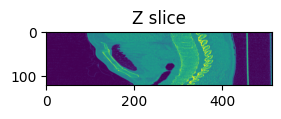

In [ ]:
import SimpleITK as sitk
import numpy as np
import glob
import matplotlib.pyplot as plt

nodule_index = 123
seriesuid = candidates.loc[nodule_index, "seriesuid"]
mhd_path = "subset0/" + seriesuid + ".mhd"
ct_mhd = sitk.ReadImage(mhd_path)
ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
ct_a = ct_a.clip(-1000, 1000, ct_a)
ct_a.shape

x=ct_a.shape[0]//2
y=ct_a.shape[1]//2
z=ct_a.shape[2]//2

zslice=ct_a[:,:,z]
yslice=ct_a[:,y,:]
xslice=ct_a[x,:,:]

plt.subplot(1,2,1)
plt.imshow(zslice)
plt.title("Z slice")





Text(0.5, 1.0, 'Y slice')

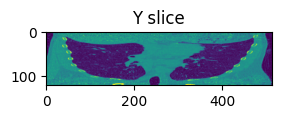

In [ ]:
plt.subplot(1,2,1)
plt.imshow(yslice)
plt.title("Y slice")



Text(0.5, 1.0, 'X slice')

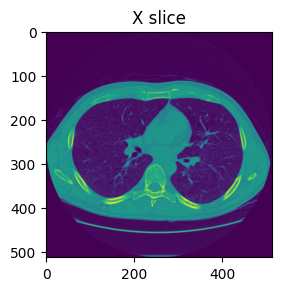

In [ ]:
plt.subplot(1,2,1)
plt.imshow(xslice)
plt.title("X slice")

## 3. Create Data Tensors

The neural network model we will build with PyTorch requires the data to be presented in the form of a torch tensor. The input tensor should be 4-dimensional, with the dimensions representing the nodule index, channel, row, and column, respectively.

3.1 Write a double for-loop to extract the CT scan data for **the first 5,000*** nodules:
- The outer for loop goes through all the distince seriesuid's.
- For each iteration of the outer loop, load the corresponding CT-scan file and create a torch tensor to represent the scan.
- Create an inner-loop that goes through the nodules corresponding to the seriesuid:
    - Load the (index, row, col) tuple of this nodule from the data frame.
    - Extract a 32x48x48 chunk centered at the (index, row, col). If the nodule is near the edge of the image and there is not enough indices to extract, please pad with zeros to keep the overall shape unchanged.
    - Use a 4D tensor to contain all the 32x48x48 chunks. The first dimension of the 4D tensor is the index of nodule.

You may modify the above procedure as you like. Make sure that you are able to obtain a 4D tensor that contains all nodule data. **Display the shape of the 4D tensor.** The shape of the tensor should be (5000, 32, 48, 48).

**Remark** Due to the memory limit, it is impossible to load all nodule images into simultanously. Therefore, the number of nodules required in this section is reduced to 5,000. Feel free to adjust this number to prevent the out-of-memory error.

In [ ]:
import SimpleITK as sitk
import numpy as np
import torch
numnodules=5000
chunks = torch.zeros([numnodules, 32, 48, 48])
labels=torch.zeros([numnodules])


In [ ]:

count=0

unique_series_id=candidates['seriesuid'].unique()
for id in unique_series_id:

 mhd_path = "subset0/" + id + ".mhd"

 ct_mhd = sitk.ReadImage(mhd_path)
 ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
 ct_a = ct_a.clip(-1000, 1000, ct_a)

 nodule= candidates[candidates['seriesuid']==id]
 for nodule_index in nodule.index:
      index,row,col= nodule.loc[nodule_index,["index", "row", "col"]]
      index=int(index)
      row=int(row)
      col=int(col)
      ct_chuck= torch.zeros([32, 48, 48])
      chunk = ct_a[(index-16):(index+16),(row-24):(row+24), (col-24):(col+24)]
      chunkindex,chunkrow,chunkcol=chunk.shape

      ct_chuck[:chunkindex, :chunkrow, :chunkcol]=torch.tensor(chunk)

      chunks[count, :, :, :]=ct_chuck
      labels[count]=nodule.loc[nodule_index,'class']
      count+=1

      if count % 100 == 0:

        print(count)

        if count==5000:
          break

        if count==5000:
          break



100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000


IndexError: index 5000 is out of bounds for dimension 0 with size 5000

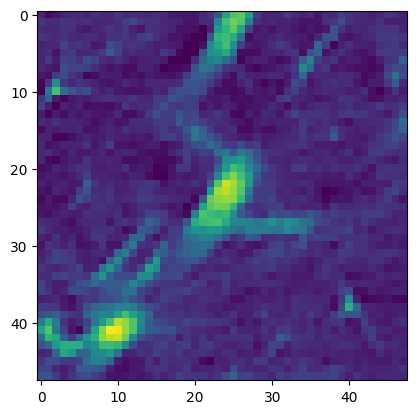

In [ ]:
nodule_index=342
plt.imshow(chunks[nodule_index, 16, :, :])

3.2 Create a 1D tensor to contain all the class information.

In [ ]:
class_tesnor=torch.tensor(malignant['class'].values)
display(class_tesnor)

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

3.3 Split the 4D tensor into a training set and a test set. Display their shapes.

In [ ]:
from sklearn.model_selection import train_test_split
chunkstrain,chunkstest,labelstrain,labelstest=train_test_split(chunks,labels,test_size=0.2)
print(chunkstrain.shape,labelstrain.shape)
print(chunkstest.shape,labelstest.shape)

torch.Size([4000, 32, 48, 48]) torch.Size([4000])
torch.Size([1000, 32, 48, 48]) torch.Size([1000])


## 4. Model Design and Implementation

4.1 Design a neural network model with only a flatten layer and two dense layers for classifying lung nodules. You may experiment with different sizes for the hidden layers to improve the training results.

In [ ]:
import torch.nn as nn
import torch.optim as optim

model= nn.Sequential(
    nn.Flatten(),
    nn.Linear(32*48*48,2),
    nn.LogSoftmax(dim=1))

print(model)



Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=73728, out_features=2, bias=True)
  (2): LogSoftmax(dim=1)
)


4.2 Create an object to represent the loss function.

In [ ]:
lossfunction=nn.NLLLoss()



4.3 Create an object to represent the optimizer.

In [ ]:
learningrate= 1e-2
optimizer=optim.SGD(model.parameters(), lr=learningrate)

4.4 Create a function to represent the training loop.


In [ ]:
import torch
dataset=torch.utils.data.TensorDataset(chunkstrain,labelstrain)
trainloader=torch.utils.data.DataLoader(dataset,batch_size=64,shuffle=True)

4.5 Execute the training loop. Display the change of training loss during the training process. Choose a reasonable value for the number of training epochs based on your observations.

In [ ]:
nepochs=10
for epoch in range(nepochs):
  for img, label in trainloader:
    out = model(img)
    loss=lossfunction(out, label.long())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  print("Epoch: %d, Loss: %f" % (epoch, float(loss)))


Epoch: 0, Loss: 0.000000
Epoch: 1, Loss: 0.000000
Epoch: 2, Loss: 0.000000
Epoch: 3, Loss: 0.000000
Epoch: 4, Loss: 0.000000
Epoch: 5, Loss: 0.000000
Epoch: 6, Loss: 0.019481
Epoch: 7, Loss: 0.000000
Epoch: 8, Loss: 0.000000
Epoch: 9, Loss: 0.000000


## 5. Model Evaluation and Analysis

5.1 Obtain the model's prediction on the test set.

In [ ]:
prob= model(chunkstest)

pred=torch.max(prob,dim=1)

print(pred)


torch.return_types.max(
values=tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         

5.2 Calculate the report the following metrics:
- accuracy
- precision
- recall

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
acc= accuracy_score(labelstest,pred.indices)
print("Accuracy:",acc)

precision= precision_score(labelstest,pred.indices)
print("Precision:",precision)

recall=recall_score(labelstest,pred.indices)
print("Recall:",recall)


Accuracy: 0.947
Precision: 0.0
Recall: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


5.3: Discuss the model's performance.

In [ ]:
# The accuracy is very high but the precison and recall is very low in my model.

## 6. Data Augmentation and Retraining

To enhance the model's performance, it is essential to increase the number of malignant instances. Apply random shifting and rotation to generate new training instances, ensuring an equal number of instances in each class within the training set.

6.1 Augment the number of malignent instances in the training set.

In [ ]:
mailgantinsatnce=malignant[malignant['class']==1]
print("Total of the malignet instanes",len(mailgantinsatnce))
mailgantinsatnce.head()

Total of the malignet instanes 138


,seriesuid,class,index,row,col
1512,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,1,33.0,348.0,110.0
2225,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,1,56.0,338.0,409.0
2400,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,1,68.0,286.0,425.0
3109,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,1,187.0,351.0,427.0
5070,1.3.6.1.4.1.14519.5.2.1.6279.6001.124154461048...,1,41.0,229.0,458.0


6.2 Retrain the neural network model on the new training set.

In [ ]:
nepochs2=11
for epoch in range(nepochs2):
  for img, label in trainloader:
    out = model(img)
    loss=lossfunction(out, label.long())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 16.717077
Epoch: 1, Loss: 9.704681
Epoch: 2, Loss: 1.507029
Epoch: 3, Loss: 0.306019
Epoch: 4, Loss: 0.674204
Epoch: 5, Loss: 4.421586
Epoch: 6, Loss: 0.994174
Epoch: 7, Loss: 0.819180
Epoch: 8, Loss: 23.336052
Epoch: 9, Loss: 16.717077
Epoch: 10, Loss: 10.812561


6.3 Perform model evaluation and compare the performance of the new model to the old model.

In [ ]:
prob= model(chunkstest)

pred=torch.max(prob,dim=1)

print(pred)

print("Accuracy:",acc)

precision= precision_score(labelstest,pred.indices)
print("Precision:",precision)

recall=recall_score(labelstest,pred.indices)
print("Recall:",recall)

# The new or old model performance are the same with acurracy , preciosn and recall

torch.return_types.max(
values=tensor([ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00, -3.6955e-06,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 7. (Optional for Undergraduates) Training with Additional Data
Train the neural network model using **all instances** from `subset0.zip`. The program should implement an iterative loading process to ensure the data stays within memory limits. For each iteration, construct a balanced dataset and apply image augmentation. Please optimize the pipeline to eliminate redundant operations and provide a final evaluation of the model's performance.